In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ==========================================
# PART 1: DATA PREPROCESSING
# ==========================================

# 1. Reading the file
print("--- Loading Data ---")
df = pd.read_csv('samples.csv') # cse-cic-ids2018 dataset
print(f"Original shape: {df.shape}")

# 2. Data Cleaning
# Remove columns that are useless for training (Identifiers & Timestamps)
cols_to_drop = ['SRC_IP', 'DST_IP', 'TIME_FIRST', 'TIME_LAST', 'SCENARIO', 'TLS_SNI']
# We use errors='ignore' so the code doesn't stop if a column doesn't exist
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Handling Missing Values
# Fill empty cells with 0 (e.g., empty TLS_JA3 means no encryption)
df_clean = df_clean.fillna(0)

# 4. Converting text to numbers (Encoding)
# The model doesn't understand words, we need to convert TLS_JA3 and SRC_PORT to numbers
le = LabelEncoder()

# Find all 'object' (text) type columns and convert them
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"Encoded column: {col}")

# 5. Splitting data into Features (X) and Target (y)
X = df_clean.drop('CLASS', axis=1)
y = df_clean['CLASS']

# 6. Train and Test Split
# stratify=y means: keep the same proportions of attacks in Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Preprocessing Results ---")
print(f"Features Training Shape (X_train): {X_train.shape}")
print(f"Features Test Shape (X_test): {X_test.shape}")
print(f"Target Distribution (Train): \n{y_train.value_counts(normalize=True)}")

--- Loading Data ---
Original shape: (67469, 61)
Encoded column: SRC_PORT
Encoded column: TLS_JA3

--- Preprocessing Results ---
Features Training Shape (X_train): (53975, 54)
Features Test Shape (X_test): (13494, 54)
Target Distribution (Train): 
CLASS
0    0.827365
1    0.172635
Name: proportion, dtype: float64


In [3]:
# ==========================================
# PART 2: OPTIMIZATION AND TRAINING
# ==========================================

print("\n--- Starting Optimization (Phase 2) ---")

# 1. Normalization (scaling uniformization)
# We calculate means only on Train to avoid Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("1. Normalization completed.")

# 2. Feature Selection (dimensionality reduction)
# We use a preliminary model to identify important columns
print("2. Selecting best features...")
selector = SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42))
selector.fit(X_train_scaled, y_train)

# Apply the selection on Train and Test
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# How many features remained?
selected_feat_count = X_train_selected.shape[1]
print(f"   -> Features before: {X_train.shape[1]}")
print(f"   -> Features after selection: {selected_feat_count}")

# 3. Hyperparameter Optimization (Grid Search) - searching for the best parameters
print("3. Searching for the best hyperparameters (GridSearch)...")
param_grid = {
    'n_estimators': [50, 100],       # Number of trees
    'max_depth': [10, 20, None],     # Tree depth
    'min_samples_split': [2, 5]      # Minimum samples required to split a node
}

# Test all possible combinations
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_selected, y_train)

# 4. Extracting the best model and evaluation
best_model = grid_search.best_estimator_
print(f"\n[OK] Best parameters found: {grid_search.best_params_}")

# Prediction with the best model
y_pred = best_model.predict(X_test_selected)

print("\n--- FINAL RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Starting Optimization (Phase 2) ---
1. Normalization completed.
2. Selecting best features...
   -> Features before: 54
   -> Features after selection: 19
3. Searching for the best hyperparameters (GridSearch)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

[OK] Best parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

--- FINAL RESULTS ---
Accuracy: 99.97%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11165
           1       1.00      1.00      1.00      2329

    accuracy                           1.00     13494
   macro avg       1.00      1.00      1.00     13494
weighted avg       1.00      1.00      1.00     13494


Confusion Matrix:
[[11165     0]
 [    4  2325]]


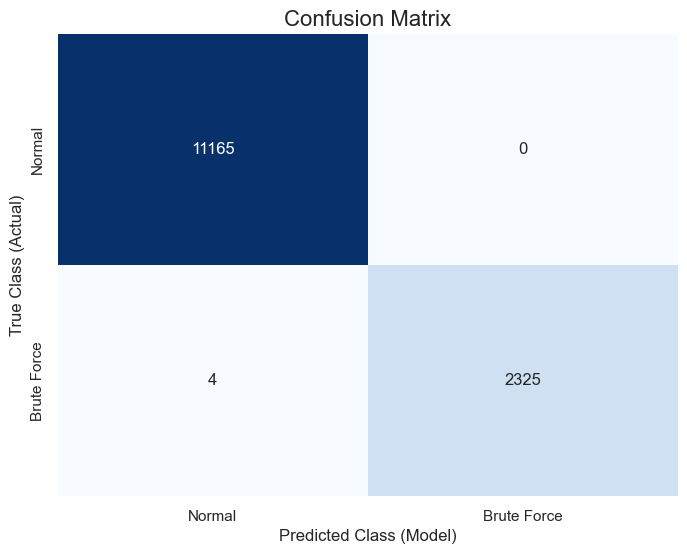

C:\Users\ayoub\AppData\Local\Temp\ipykernel_11876\197448224.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


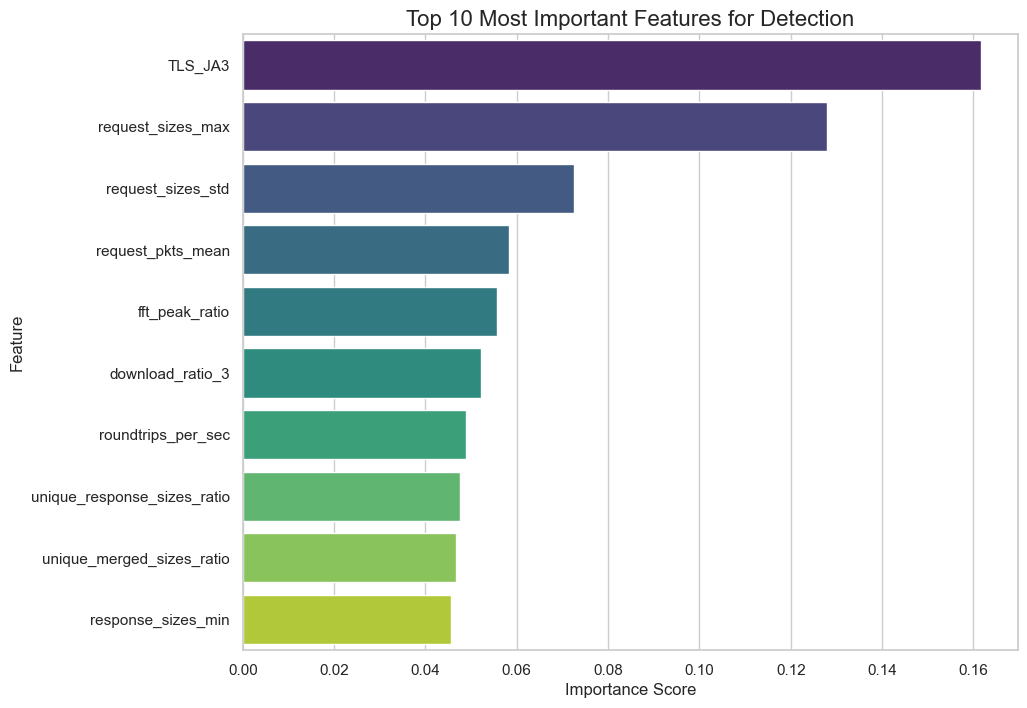


--- Complete Feature Ranking ---
                        Feature  Importance
0                       TLS_JA3    0.161665
7             request_sizes_max    0.127950
4             request_sizes_std    0.072472
8             request_pkts_mean    0.058221
18               fft_peak_ratio    0.055687
14             download_ratio_3    0.052056
3            roundtrips_per_sec    0.048781
17  unique_response_sizes_ratio    0.047472
16    unique_merged_sizes_ratio    0.046601
10           response_sizes_min    0.045570
1                      DURATION    0.043541
9              request_pkts_std    0.038217
13             download_ratio_2    0.037314
11           response_sizes_q80    0.032863
2                  ppi_duration    0.029502
6             request_sizes_q80    0.029181
15           unique_sizes_ratio    0.027740
5             request_sizes_min    0.026310
12          request_sizes_std_2    0.018858


In [4]:
# ==========================================
# PART 3: RESULTS VISUALIZATION
# ==========================================

# Setting up the general style for charts
sns.set(style="whitegrid")

# 1. Confusion Matrix Chart
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Drawing the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Brute Force'],
            yticklabels=['Normal', 'Brute Force'])

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Class (Actual)', fontsize=12)
plt.xlabel('Predicted Class (Model)', fontsize=12)
plt.show()

# 2. Feature Importance Chart
# We need to retrieve the names of the 19 remaining features after Selection
# selector is the tool used in phase 2
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

# Retrieve the importance of each feature from the final model
importances = best_model.feature_importances_

# Group them in a DataFrame and sort them
feature_imp_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Chart of the 10 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')

plt.title('Top 10 Most Important Features for Detection', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

# Display the complete list for the appendix
print("\n--- Complete Feature Ranking ---")
print(feature_imp_df)

In [5]:
# ==========================================
# PART 4: SAVING THE MODEL
# ==========================================

import joblib
# Save
model_data = {
    'model': best_model,
    'scaler': scaler,
    'selector': selector,
    'features_names': X.columns,
    'X_test': X_test,
    'y_test': y_test
}
joblib.dump(model_data, 'detection_system.pkl')
print("[OK] System saved successfully!")

[OK] System saved successfully!
